In [ ]:
!pip install stability-sdk pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 61.5 MB/s eta 0:00:00
  Attempting uninstall: grpcio
    Found existing installation: grpcio 1.78.0
    Uninstalling grpcio-1.78.0:
      Successfully uninstalled grpcio-1.78.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires grpcio>=1.71.2, but you have grpcio 1.63.2 which is incompatible.


In [ ]:
import os
os.environ['STABILITY_API_KEY'] = 'sk-VHiSxuAbfEFcgwwMbktHir0V1oEvwl1WMJTaOzdvtW0P3QrL'

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

def print_images(image_dir):
  image_files = [f for f in os.listdir(image_dir) if f.endswith(('.png'))]

  if not image_files:
      print(f"No images found in {image_dir}")
  else:
      print(f"Displaying images from {image_dir}:")
      plt.figure(figsize=(10, 10))
      for i, image_file in enumerate(image_files):
          img_path = os.path.join(image_dir, image_file)
          img = mpimg.imread(img_path)

          plt.subplot(2, (len(image_files) + 1) // 2, i + 1) # Adjust subplot grid dynamically
          plt.imshow(img)
          plt.title(image_file)
          plt.axis('off')
      plt.tight_layout()
      plt.show()

In [ ]:
import io
import os
from PIL import Image
from stability_sdk import client
import stability_sdk.interfaces.gooseai.generation.generation_pb2 as generation

# Initialise the API client
stability_api = client.StabilityInference(
    key=os.environ.get('STABILITY_API_KEY'),
    verbose=True,
    engine="stable-diffusion-xl-1024-v1-0"
)

# Generate an image
prompt = "a white siamese cat, studio lighting, photorealistic"

answers = stability_api.generate(
    prompt=prompt,
    steps=30,  # More steps = better quality but slower
    cfg_scale=7.0,  # How strictly to follow the prompt
    width=1024,
    height=1024,
    samples=1,  # Number of images to generate
    sampler=generation.SAMPLER_K_DPMPP_2M
)

# Save the image
for resp in answers:
    for artifact in resp.artifacts:
        if artifact.type == generation.ARTIFACT_IMAGE:
            img = Image.open(io.BytesIO(artifact.binary))
            img.save(f"sample_data/generated/generated_{prompt[:30]}.png")
            print(f"Saved image: generated_{prompt[:30]}.png")




INFO:stability_sdk.client:Opening channel to grpc.stability.ai:443
INFO:stability_sdk.client:Channel opened to grpc.stability.ai:443
INFO:stability_sdk.client:Sending request.
INFO:stability_sdk.client:Got answer e1d94115-4a1f-4699-acf6-4f81f347e059 with artifact types ['ARTIFACT_IMAGE', 'ARTIFACT_CLASSIFICATIONS'] in 4.11s


Saved image: generated_a white siamese cat, studio li.png


Displaying images from sample_data/generated:


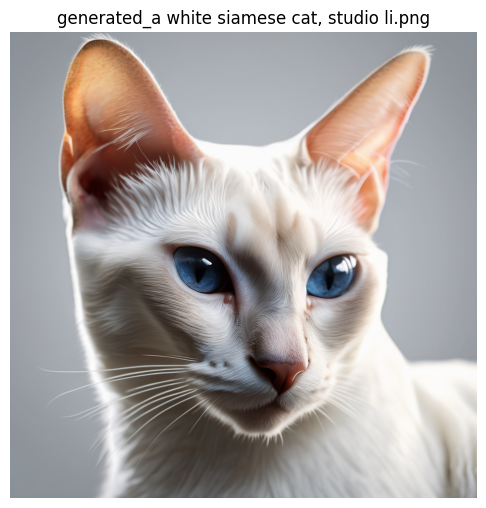

In [ ]:
print_images("sample_data/generated")

In [ ]:
#Experiment with Parameters

prompts = [
    "a white siamese cat, studio lighting",
    "a white siamese cat, dramatic lighting, dark background",
    "a white siamese cat, outdoor setting, natural light"
]

for i, prompt in enumerate(prompts):
    answers = stability_api.generate(
        prompt=prompt,
        steps=30,
        cfg_scale=7.0,
        width=1024,
        height=1024,
        samples=1
    )

    for resp in answers:
        for artifact in resp.artifacts:
            if artifact.type == generation.ARTIFACT_IMAGE:
                img = Image.open(io.BytesIO(artifact.binary))
                img.save(f"sample_data/generated/params/variation_{i}.png")
                print(f"Generated variation_{i}.png")

INFO:stability_sdk.client:Sending request.
INFO:stability_sdk.client:Got answer d72215ca-2b79-4824-ac8c-8bb639387408 with artifact types ['ARTIFACT_IMAGE', 'ARTIFACT_CLASSIFICATIONS'] in 3.08s
INFO:stability_sdk.client:Sending request.


Generated variation_0.png


INFO:stability_sdk.client:Got answer fcd65c1f-4fc7-48e7-9d12-4dae041c646d with artifact types ['ARTIFACT_IMAGE', 'ARTIFACT_CLASSIFICATIONS'] in 2.99s
INFO:stability_sdk.client:Sending request.


Generated variation_1.png


INFO:stability_sdk.client:Got answer c550cb3f-3218-407b-ba5d-6be7786ef663 with artifact types ['ARTIFACT_IMAGE', 'ARTIFACT_CLASSIFICATIONS'] in 2.96s


Generated variation_2.png


Displaying images from sample_data/generated/params:


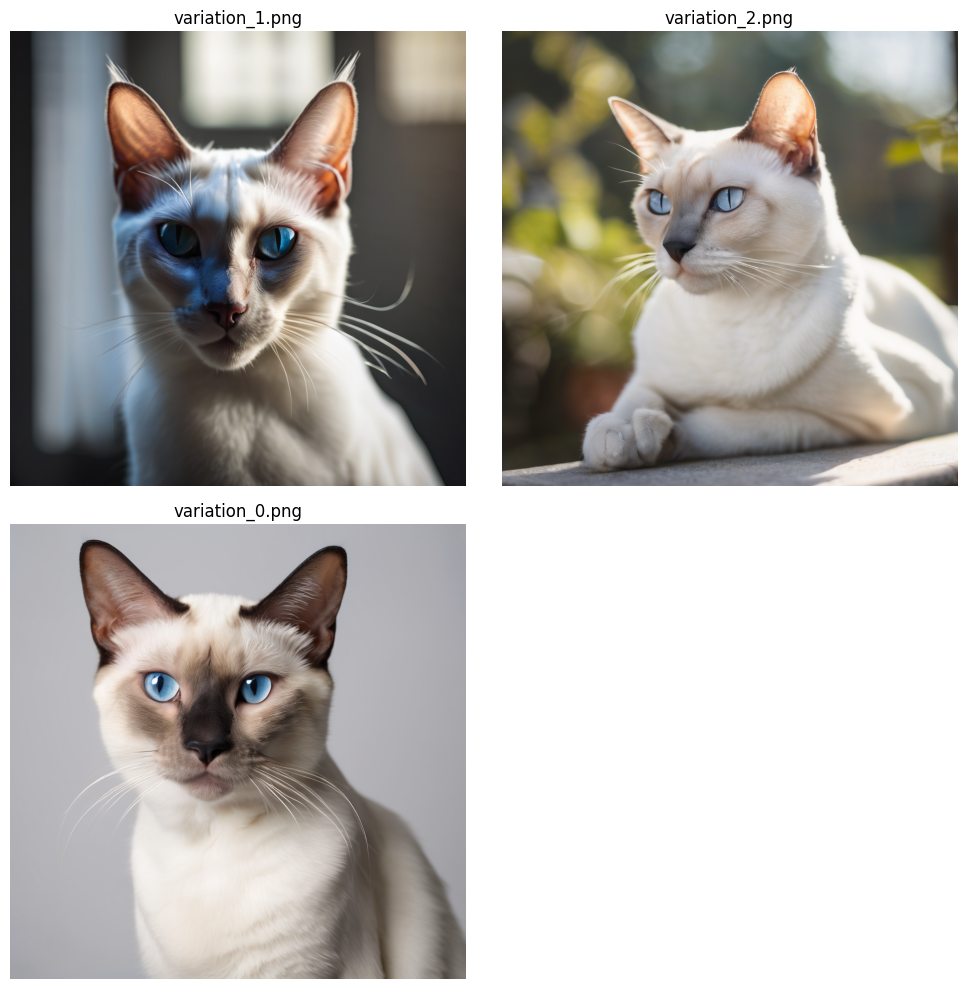

In [ ]:
print_images("sample_data/generated/params")

In [ ]:
#Exploration

prompt = "a white siamese cat, outdoor setting, natural light"
params = {'params1': {'steps':40, 'cfg_scale':4.0, 'resolution':1024}, 'params2': {'steps':20, 'cfg_scale':10.0, 'resolution':512}}

for param_name, param_values in params.items():
    answers = stability_api.generate(
        prompt=prompt,
        steps=param_values['steps'],
        cfg_scale=param_values['cfg_scale'],
        width=param_values['resolution'],
        height=param_values['resolution'],
        samples=1
    )
    for resp in answers:
      for artifact in resp.artifacts:
            if artifact.type == generation.ARTIFACT_IMAGE:
                img = Image.open(io.BytesIO(artifact.binary))
                img.save(f"sample_data/generated/explore/image_with_{param_name}.png")
                print(f"Generated variation_{i}.png")

INFO:stability_sdk.client:Sending request.
INFO:stability_sdk.client:Got answer 8b54b608-fa40-4384-ad33-ee88d040bc2f with artifact types ['ARTIFACT_IMAGE', 'ARTIFACT_CLASSIFICATIONS'] in 4.08s
INFO:stability_sdk.client:Sending request.


Generated variation_2.png


INFO:stability_sdk.client:Got answer cfff2377-2d70-4b91-9c62-aed37e65ad69 with artifact types ['ARTIFACT_IMAGE', 'ARTIFACT_CLASSIFICATIONS'] in 1.95s


Generated variation_2.png


Displaying images from sample_data/generated/explore:


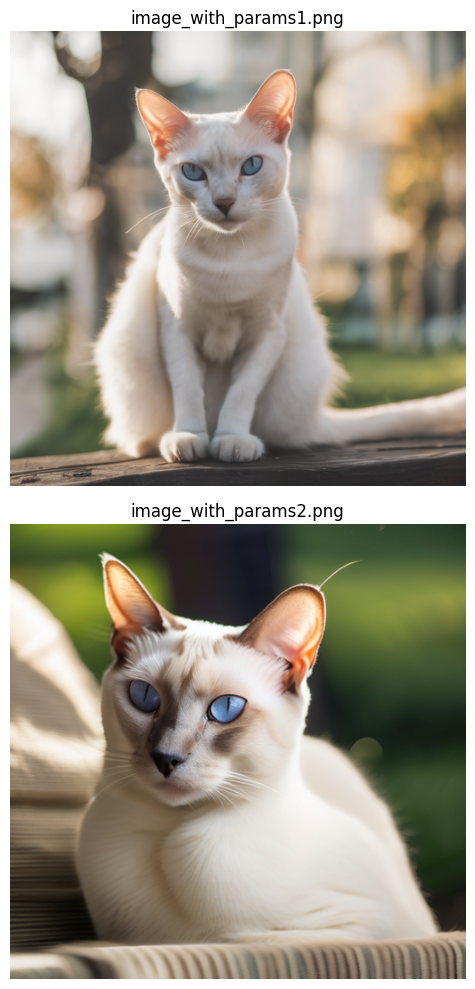

In [ ]:
print_images("sample_data/generated/explore")

#Observations

With parameters change, the images are not very accurate. With increased steps and reduced scale the shape of cat resembles somewhat like Kangaroo. With reduced steps and increased scale along with reduced resolution, the cat shape resembles a bird and full body is missing.